In [2]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ipynb.fs.defs.competition1 import create_sparse_matrix, compute_stats

In [3]:
file = "data/train.csv"
df = pd.read_csv(file, header=0)
df.head()

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0


In [4]:
y = df["rating"]
x = df.drop(columns="rating")
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42, stratify=df.rating)

## First Model

In [ ]:
class PMF:
    """
    PMF con Huber loss como objetivo (más cercano a MAE que MSE,
    y diferenciable en todo su dominio a diferencia del MAE puro).

    Huber(e, δ) = { 0.5 * e²          si |e| ≤ δ
                  { δ * (|e| - 0.5*δ)  si |e| > δ

    Con δ → 0 converge a MAE; con δ → ∞ converge a MSE.
    δ = 1.0 es un buen punto de partida para ratings 1-10.
    """

    def __init__(self, n_factors=10, lambda_U=0.01, lambda_V=0.01,
                 lr=0.001, n_epochs=100, batch_size=1024,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='adam', huber_delta=1.0, log_every=1):
        self.n_factors    = n_factors
        self.lambda_U     = lambda_U
        self.lambda_V     = lambda_V
        self.lr           = lr
        self.n_epochs     = n_epochs
        self.batch_size   = batch_size
        self.clip_min     = clip_min
        self.clip_max     = clip_max
        self.random_state = random_state
        self.optimizer    = optimizer
        self.huber_delta  = huber_delta   # δ del Huber loss, con esto se controla a partir de que error pasa de ser quadrática a lineal la penalización
        self.log_every    = log_every     # imprimir log cada N épocas

        self.U = self.V = None
        self.history = []   # lista de dicts con métricas por época

    # ── Inicialización ────────────────────────────────────────────────────────
    def _init_factors(self, n_users, n_items):
        rng   = np.random.default_rng(self.random_state)
        scale = 1 / np.sqrt(self.n_factors)
        self.U = rng.normal(0, scale, (n_users, self.n_factors))
        self.V = rng.normal(0, scale, (n_items, self.n_factors))

        if self.optimizer == 'adam':
            self.mU = np.zeros_like(self.U); self.vU = np.zeros_like(self.U)
            self.mV = np.zeros_like(self.V); self.vV = np.zeros_like(self.V)
            self._adam_t = 0

    # ── Huber loss & gradiente ────────────────────────────────────────────────
    def _huber_loss_and_grad(self, errors):
        """
        Devuelve (loss_media, pseudo-gradiente respecto a la predicción).
        grad = -dL/d(pred) = dL/d(error) con signo para el update.
        """
        d    = self.huber_delta
        abs_e = np.abs(errors)
        mask  = abs_e <= d

        loss  = np.where(mask, 0.5 * errors ** 2, d * (abs_e - 0.5 * d))
        # dHuber/d(error)
        dgrad = np.where(mask, errors, d * np.sign(errors))

        return loss.mean(), dgrad   # grad wrt error; update usa -dgrad

    # ── Métricas de evaluación ────────────────────────────────────────────────
    def _metrics(self, user_idx, item_idx, ratings):
        preds  = np.clip(
            np.sum(self.U[user_idx] * self.V[item_idx], axis=1),
            self.clip_min, self.clip_max
        )
        errors = ratings - preds
        _, dgrad = self._huber_loss_and_grad(errors)
        huber = np.where(
            np.abs(errors) <= self.huber_delta,
            0.5 * errors ** 2,
            self.huber_delta * (np.abs(errors) - 0.5 * self.huber_delta)
        ).mean()
        mae   = np.mean(np.abs(errors))
        rmse  = np.sqrt(np.mean(errors ** 2))
        return {'huber': huber, 'mae': mae, 'rmse': rmse}

    # ── Adam update ───────────────────────────────────────────────────────────
    def _adam_update(self, param, m, v, grad, beta1=0.9, beta2=0.999, eps=1e-8):
        self._adam_t += 1
        m[:] = beta1 * m + (1 - beta1) * grad
        v[:] = beta2 * v + (1 - beta2) * grad ** 2
        m_hat = m / (1 - beta1 ** self._adam_t)
        v_hat = v / (1 - beta2 ** self._adam_t)
        param -= self.lr * m_hat / (np.sqrt(v_hat) + eps)

    # ── Entrenamiento ─────────────────────────────────────────────────────────
    def fit(self, x_train, y_train, x_val, y_val,
            user_map, item_map, patience=10):

        train_users = x_train['user'].map(user_map).values
        train_items = x_train['item'].map(item_map).values
        train_r     = y_train.values.astype(np.float64)

        val_mask  = x_val['user'].isin(user_map) & x_val['item'].isin(item_map)
        val_users = x_val.loc[val_mask, 'user'].map(user_map).values
        val_items = x_val.loc[val_mask, 'item'].map(item_map).values
        val_r     = y_val[val_mask].values.astype(np.float64)

        n_users, n_items = len(user_map), len(item_map)
        self._init_factors(n_users, n_items)

        n_samples  = len(train_r)
        rng        = np.random.default_rng(self.random_state)
        best_val   = np.inf
        best_U, best_V = self.U.copy(), self.V.copy()
        no_improve = 0

        print(f"{'Epoch':>6}  {'Train Huber':>12}  {'Train MAE':>10}  {'Train RMSE':>11}  "
              f"{'Val Huber':>10}  {'Val MAE':>8}  {'Val RMSE':>9}  {'Status':>12}")
        print("-" * 95)

        for epoch in range(self.n_epochs):
            perm   = rng.permutation(n_samples)
            u_shuf = train_users[perm]
            i_shuf = train_items[perm]
            r_shuf = train_r[perm]

            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                u_b = u_shuf[start:end]
                i_b = i_shuf[start:end]
                r_b = r_shuf[start:end]

                U_b    = self.U[u_b]
                V_b    = self.V[i_b]
                errors = r_b - np.sum(U_b * V_b, axis=1)

                # Gradiente del Huber respecto al error → -dL/d(pred)
                _, dgrad = self._huber_loss_and_grad(errors)

                # dL/dU = -dgrad * V  +  lambda * U  (regla cadena)
                grad_U = -dgrad[:, None] * V_b + self.lambda_U * U_b
                grad_V = -dgrad[:, None] * U_b + self.lambda_V * V_b

                if self.optimizer == 'adam':
                    for idx in np.unique(u_b):
                        mask = u_b == idx
                        self._adam_update(
                            self.U[idx], self.mU[idx], self.vU[idx],
                            grad_U[mask].mean(axis=0)
                        )
                    for idx in np.unique(i_b):
                        mask = i_b == idx
                        self._adam_update(
                            self.V[idx], self.mV[idx], self.vV[idx],
                            grad_V[mask].mean(axis=0)
                        )
                else:
                    for idx in np.unique(u_b):
                        self.U[idx] -= self.lr * grad_U[u_b == idx].mean(axis=0)
                    for idx in np.unique(i_b):
                        self.V[idx] -= self.lr * grad_V[i_b == idx].mean(axis=0)

            # ── Métricas ──────────────────────────────────────────────────────
            tr = self._metrics(train_users, train_items, train_r)
            vl = self._metrics(val_users,   val_items,   val_r)

            status = ''
            if vl['mae'] < best_val:
                best_val       = vl['mae']
                best_U, best_V = self.U.copy(), self.V.copy()
                no_improve     = 0
                status         = '✔ best'
            else:
                no_improve += 1
                status = f'no imp {no_improve}/{patience}'
                if no_improve >= patience:
                    self.history.append({'epoch': epoch, **{f'train_{k}': v for k, v in tr.items()},
                                         **{f'val_{k}': v for k, v in vl.items()}})
                    print(f"{epoch+1:>6}  {tr['huber']:>12.4f}  {tr['mae']:>10.4f}  {tr['rmse']:>11.4f}  "
                          f"{vl['huber']:>10.4f}  {vl['mae']:>8.4f}  {vl['rmse']:>9.4f}  "
                          f"{'early stop':>12}")
                    print(f"\nEarly stopping época {epoch+1}  |  best val MAE: {best_val:.4f}")
                    break

            self.history.append({
                'epoch': epoch,
                **{f'train_{k}': v for k, v in tr.items()},
                **{f'val_{k}':   v for k, v in vl.items()}
            })

            if (epoch + 1) % self.log_every == 0:
                print(f"{epoch+1:>6}  {tr['huber']:>12.4f}  {tr['mae']:>10.4f}  {tr['rmse']:>11.4f}  "
                      f"{vl['huber']:>10.4f}  {vl['mae']:>8.4f}  {vl['rmse']:>9.4f}  {status:>12}")

        self.U, self.V = best_U, best_V
        return self

    # ── Plot ──────────────────────────────────────────────────────────────────
    def plot_loss(self):
        df      = pd.DataFrame(self.history).set_index('epoch')
        metrics = ['huber', 'mae', 'rmse']
        titles  = ['Huber Loss (objetivo)', 'MAE', 'RMSE']

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        for ax, m, title in zip(axes, metrics, titles):
            ax.plot(df[f'train_{m}'], label='Train', linewidth=2)
            ax.plot(df[f'val_{m}'],   label='Val',   linewidth=2)
            best_ep = int(df[f'val_{m}'].idxmin())
            ax.axvline(best_ep, color='red', linestyle='--',
                       label=f'Best={best_ep} ({df[f"val_{m}"].min():.4f})')
            ax.set_title(title)
            ax.set_xlabel('Época')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.4)

        fig.suptitle('PMF — Training History', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ── Predicción test ───────────────────────────────────────────────────────
    def predict_test(self, x_test, user_map, item_map,
                     user_means, item_means, global_mean,
                     cold_start_unknown_user='global_mean',
                     cold_start_unknown_item='user_mean',
                     cold_start_both='const_7'):

        def _cold(strat, user_idx=None, item_idx=None):
            if strat == 'item_mean':
                v = item_means[item_idx] if item_idx is not None else np.nan
            elif strat == 'user_mean':
                v = user_means[user_idx] if user_idx is not None else np.nan
            elif strat == 'global_mean':
                v = global_mean
            elif strat.startswith('const_'):
                v = float(strat.split('_')[1])
            else:
                v = np.nan
            return global_mean if np.isnan(v) else v

        ids, preds = [], []
        for _, row in tqdm(x_test.iterrows(), total=len(x_test), desc='Predicting'):
            row_id, user_id, item_id = row.iloc[0], row.iloc[1], row.iloc[2]
            ids.append(row_id)

            if user_id not in user_map and item_id not in item_map:
                preds.append(_cold(cold_start_both))
            elif user_id not in user_map:
                preds.append(_cold(cold_start_unknown_user, item_idx=item_map[item_id]))
            elif item_id not in item_map:
                preds.append(_cold(cold_start_unknown_item, user_idx=user_map[user_id]))
            else:
                p = float(np.dot(self.U[user_map[user_id]], self.V[item_map[item_id]]))
                preds.append(np.clip(p, self.clip_min, self.clip_max))

        return pd.DataFrame({'id': ids, 'rating': preds})

 Epoch   Train Huber   Train MAE   Train RMSE   Val Huber   Val MAE   Val RMSE        Status
-----------------------------------------------------------------------------------------------
     1        3.0231      3.4736       4.2856      4.5499    5.0250     5.6885        ✔ best
     2        2.7388      3.1783       4.0248      4.3922    4.8663     5.5575        ✔ best
     3        2.3971      2.8287       3.6742      4.2193    4.6917     5.4029        ✔ best
     4        2.2818      2.7131       3.5225      4.0239    4.4949     5.2313        ✔ best
     5        2.1621      2.5913       3.3844      3.8054    4.2725     5.0405        ✔ best
     6        2.0319      2.4594       3.2331      3.6343    4.1010     4.8757        ✔ best
     7        1.8794      2.3030       3.0520      3.4685    3.9334     4.7198        ✔ best
     8        1.7998      2.2224       2.9478      3.3204    3.7828     4.5824        ✔ best
     9        1.6975      2.1174       2.8187      3.1881    3.6487

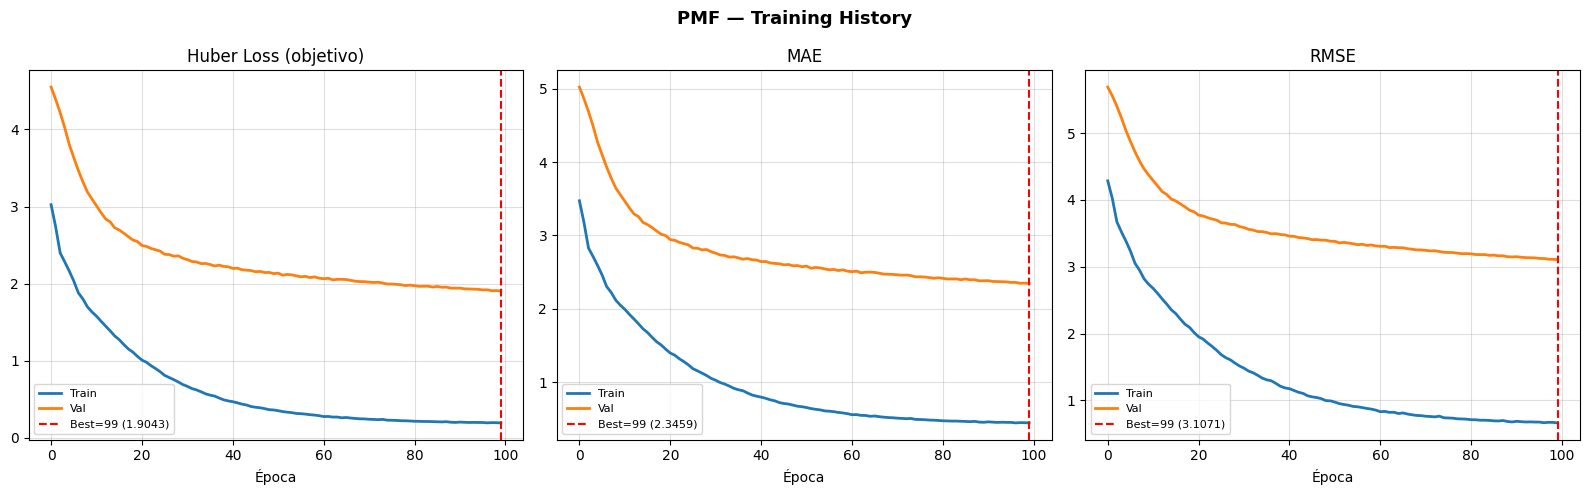

In [8]:
sparse_matrix, user_map, item_map = create_sparse_matrix(x_train, y_train)
user_means, item_means, global_mean = compute_stats(sparse_matrix)

pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.01,
    lambda_V   = 0.01,
    lr         = 0.1,   # Adam es mucho más estable con lr fijo
    n_epochs   = 100,
    batch_size = 2048,
    optimizer  = 'adam'   # <-- cambio clave
)

pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()

In [14]:
pmf = PMF(
    n_factors   = 20,
    lambda_U    = 0.1,    # era 0.01 → subir x10
    lambda_V    = 0.1,
    lr          = 0.1,  # bajar lr
    n_epochs    = 100,
    batch_size  = 2048,
    optimizer   = 'adam',
    huber_delta = 1.0,
    log_every   = 1,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()

 Epoch   Train Huber   Train MAE   Train RMSE   Val Huber   Val MAE   Val RMSE        Status
-----------------------------------------------------------------------------------------------
     1        3.6679      4.1357       4.8925      4.5862    5.0651     5.6920        ✔ best
     2        2.6219      3.0680       3.8528      4.0664    4.5395     5.2584        ✔ best
     3        2.2159      2.6490       3.4343      3.6758    4.1440     4.9007        ✔ best
     4        2.0614      2.4904       3.2505      3.3805    3.8453     4.6267        ✔ best
     5        1.9357      2.3642       3.0970      3.1537    3.6169     4.4005        ✔ best
     6        1.7959      2.2213       2.9293      2.9274    3.3868     4.1805        ✔ best
     7        1.6480      2.0706       2.7435      2.7491    3.2063     3.9971        ✔ best
     8        1.5458      1.9649       2.6149      2.5935    3.0471     3.8475        ✔ best
     9        1.4431      1.8592       2.4883      2.4911    2.9457

KeyboardInterrupt: 

In [ ]:
pmf = PMF(
    n_factors   = 20,
    lambda_U    = 0.5,    # era 0.1 → subir x5
    lambda_V    = 0.5,
    lr          = 0.1,  # bajar lr
    n_epochs    = 100,
    batch_size  = 2048,
    optimizer   = 'adam',
    huber_delta = 1.0,
    log_every   = 1,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()

 Epoch   Train Huber   Train MAE   Train RMSE   Val Huber   Val MAE   Val RMSE        Status
-----------------------------------------------------------------------------------------------
     1        5.6929      6.1895       6.5224      6.0954    6.5936     6.8446        ✔ best
     2        4.1379      4.6214       5.2467      4.6927    5.1826     5.7028        ✔ best
     3        2.7260      3.1885       3.8844      3.5632    4.0403     4.7008        ✔ best
     4        2.1416      2.5918       3.2399      3.1520    3.6256     4.2995        ✔ best
     5        1.9716      2.4130       3.0662      2.9226    3.3928     4.0719        ✔ best
     6        1.9537      2.3963       3.0337      2.8306    3.2997     3.9628        ✔ best
     7        1.8835      2.3283       2.9294      2.7245    3.1934     3.8426        ✔ best
     8        1.7556      2.1986       2.7656      2.5714    3.0381     3.6820        ✔ best
     9        1.6343      2.0769       2.5993      2.4181    2.8824

KeyboardInterrupt: 

## User and Item biases

In [19]:
class PMF:
    def __init__(self, n_factors=20, lambda_U=0.5, lambda_V=0.5,
                 lambda_bu=0.01, lambda_bi=0.01,
                 lr=0.001, n_epochs=100, batch_size=1024,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='adam', huber_delta=1.0, log_every=1,
                 use_biases=True):
        self.n_factors   = n_factors
        self.lambda_U    = lambda_U
        self.lambda_V    = lambda_V
        self.lambda_bu   = lambda_bu   # regularización bias usuario
        self.lambda_bi   = lambda_bi   # regularización bias ítem
        self.lr          = lr
        self.n_epochs    = n_epochs
        self.batch_size  = batch_size
        self.clip_min    = clip_min
        self.clip_max    = clip_max
        self.random_state = random_state
        self.optimizer   = optimizer
        self.huber_delta = huber_delta
        self.log_every   = log_every
        self.use_biases  = use_biases  # False → PMF puro sin biases

        self.U   = self.V   = None
        self.b_u = self.b_i = None     # (n_users,)  (n_items,)
        self.mu  = None                # media global (escalar)
        self.history = []

    # ── Inicialización ────────────────────────────────────────────────────────
    def _init_factors(self, n_users, n_items, global_mean):
        rng   = np.random.default_rng(self.random_state)
        scale = 1 / np.sqrt(self.n_factors)
        self.U   = rng.normal(0, scale, (n_users, self.n_factors))
        self.V   = rng.normal(0, scale, (n_items, self.n_factors))
        self.mu  = global_mean
        self.b_u = np.zeros(n_users)
        self.b_i = np.zeros(n_items)

        if self.optimizer == 'adam':
            self.mU  = np.zeros_like(self.U);   self.vU  = np.zeros_like(self.U)
            self.mV  = np.zeros_like(self.V);   self.vV  = np.zeros_like(self.V)
            self.mbu = np.zeros_like(self.b_u); self.vbu = np.zeros_like(self.b_u)
            self.mbi = np.zeros_like(self.b_i); self.vbi = np.zeros_like(self.b_i)
            self._adam_t = 0

    # ── Predicción ────────────────────────────────────────────────────────────
    def _predict_batch(self, u_idx, i_idx):
        """
        r̂_ui = μ + b_u[u] + b_i[i] + U[u] · V[i]
        Sin biases:
        r̂_ui = μ + U[u] · V[i]
        """
        dot = np.sum(self.U[u_idx] * self.V[i_idx], axis=1)
        if self.use_biases:
            return self.mu + self.b_u[u_idx] + self.b_i[i_idx] + dot
        return self.mu + dot

    # ── Huber ─────────────────────────────────────────────────────────────────
    def _huber_grad(self, errors):
        d = self.huber_delta
        return np.where(np.abs(errors) <= d, errors, d * np.sign(errors))

    # ── Métricas ──────────────────────────────────────────────────────────────
    def _metrics(self, u_idx, i_idx, ratings):
        preds  = np.clip(self._predict_batch(u_idx, i_idx), self.clip_min, self.clip_max)
        errors = ratings - preds
        huber  = np.where(
            np.abs(errors) <= self.huber_delta,
            0.5 * errors ** 2,
            self.huber_delta * (np.abs(errors) - 0.5 * self.huber_delta)
        ).mean()
        return {
            'huber': huber,
            'mae'  : np.mean(np.abs(errors)),
            'rmse' : np.sqrt(np.mean(errors ** 2))
        }

    # ── Adam update ───────────────────────────────────────────────────────────
    def _adam_update(self, param, m, v, grad, beta1=0.9, beta2=0.999, eps=1e-8):
        self._adam_t += 1
        m[:] = beta1 * m + (1 - beta1) * grad
        v[:] = beta2 * v + (1 - beta2) * grad ** 2
        param -= self.lr * (m / (1 - beta1**self._adam_t)) / \
                           (np.sqrt(v / (1 - beta2**self._adam_t)) + eps)

    # ── Entrenamiento ─────────────────────────────────────────────────────────
    def fit(self, x_train, y_train, x_val, y_val,
            user_map, item_map, patience=10):

        train_users = x_train['user'].map(user_map).values
        train_items = x_train['item'].map(item_map).values
        train_r     = y_train.values.astype(np.float64)

        val_mask    = x_val['user'].isin(user_map) & x_val['item'].isin(item_map)
        val_users   = x_val.loc[val_mask, 'user'].map(user_map).values
        val_items   = x_val.loc[val_mask, 'item'].map(item_map).values
        val_r       = y_val[val_mask].values.astype(np.float64)

        # Media global para inicializar μ
        global_mean = float(train_r.mean())
        self._init_factors(len(user_map), len(item_map), global_mean)

        n_samples  = len(train_r)
        rng        = np.random.default_rng(self.random_state)
        best_val   = np.inf
        best_state = self._save_state()
        no_improve = 0

        print(f"{'Epoch':>6}  {'Tr Huber':>9}  {'Tr MAE':>8}  {'Tr RMSE':>9}  "
              f"{'Va Huber':>9}  {'Va MAE':>8}  {'Va RMSE':>9}  {'Status':>12}")
        print("─" * 85)

        for epoch in range(self.n_epochs):
            perm   = rng.permutation(n_samples)
            u_shuf = train_users[perm]
            i_shuf = train_items[perm]
            r_shuf = train_r[perm]

            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                u_b = u_shuf[start:end]
                i_b = i_shuf[start:end]
                r_b = r_shuf[start:end]

                U_b    = self.U[u_b]
                V_b    = self.V[i_b]
                dot    = np.sum(U_b * V_b, axis=1)

                if self.use_biases:
                    preds  = self.mu + self.b_u[u_b] + self.b_i[i_b] + dot
                else:
                    preds  = self.mu + dot

                errors = r_b - preds
                dgrad  = self._huber_grad(errors)   # dL/d(error)

                # ── Gradientes ────────────────────────────────────────────────
                # dL/dU = -dgrad * V + λ_U * U
                grad_U  = -dgrad[:, None] * V_b  + self.lambda_U  * U_b
                grad_V  = -dgrad[:, None] * U_b  + self.lambda_V  * V_b

                if self.use_biases:
                    grad_bu = -dgrad + self.lambda_bu * self.b_u[u_b]
                    grad_bi = -dgrad + self.lambda_bi * self.b_i[i_b]

                # ── Updates ───────────────────────────────────────────────────
                if self.optimizer == 'adam':
                    for idx in np.unique(u_b):
                        mask = u_b == idx
                        self._adam_update(self.U[idx],   self.mU[idx],  self.vU[idx],
                                          grad_U[mask].mean(axis=0))
                        if self.use_biases:
                            self._adam_update(self.b_u[idx:idx+1], self.mbu[idx:idx+1],
                                              self.vbu[idx:idx+1],
                                              np.array([grad_bu[mask].mean()]))
                    for idx in np.unique(i_b):
                        mask = i_b == idx
                        self._adam_update(self.V[idx],   self.mV[idx],  self.vV[idx],
                                          grad_V[mask].mean(axis=0))
                        if self.use_biases:
                            self._adam_update(self.b_i[idx:idx+1], self.mbi[idx:idx+1],
                                              self.vbi[idx:idx+1],
                                              np.array([grad_bi[mask].mean()]))
                else:
                    for idx in np.unique(u_b):
                        mask = u_b == idx
                        self.U[idx]   -= self.lr * grad_U[mask].mean(axis=0)
                        if self.use_biases:
                            self.b_u[idx] -= self.lr * grad_bu[mask].mean()
                    for idx in np.unique(i_b):
                        mask = i_b == idx
                        self.V[idx]   -= self.lr * grad_V[mask].mean(axis=0)
                        if self.use_biases:
                            self.b_i[idx] -= self.lr * grad_bi[mask].mean()

            # ── Métricas por época ────────────────────────────────────────────
            tr = self._metrics(train_users, train_items, train_r)
            vl = self._metrics(val_users,   val_items,   val_r)

            if vl['mae'] < best_val:
                best_val   = vl['mae']
                best_state = self._save_state()
                no_improve = 0
                status     = '✔ best'
            else:
                no_improve += 1
                status = f'no imp {no_improve}/{patience}'

            self.history.append({'epoch': epoch + 1,
                                  **{f'train_{k}': v for k, v in tr.items()},
                                  **{f'val_{k}':   v for k, v in vl.items()}})

            if (epoch + 1) % self.log_every == 0:
                print(f"{epoch+1:>6}  {tr['huber']:>9.4f}  {tr['mae']:>8.4f}  {tr['rmse']:>9.4f}  "
                      f"{vl['huber']:>9.4f}  {vl['mae']:>8.4f}  {vl['rmse']:>9.4f}  {status:>12}")

            if no_improve >= patience:
                print(f"\nEarly stopping época {epoch+1} | best val MAE: {best_val:.4f}")
                break

        self._load_state(best_state)
        return self

    # ── Guardar / restaurar pesos ─────────────────────────────────────────────
    def _save_state(self):
        state = {'U': self.U.copy(), 'V': self.V.copy()}
        if self.use_biases:
            state.update({'b_u': self.b_u.copy(), 'b_i': self.b_i.copy()})
        return state

    def _load_state(self, state):
        self.U, self.V = state['U'], state['V']
        if self.use_biases:
            self.b_u, self.b_i = state['b_u'], state['b_i']

    # ── Plot ──────────────────────────────────────────────────────────────────
    def plot_loss(self):
        df = pd.DataFrame(self.history).set_index('epoch')
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        for ax, m, title in zip(axes, ['huber','mae','rmse'],
                                       ['Huber Loss','MAE','RMSE']):
            ax.plot(df[f'train_{m}'], label='Train', linewidth=2)
            ax.plot(df[f'val_{m}'],   label='Val',   linewidth=2)
            best_ep = int(df[f'val_{m}'].idxmin())
            ax.axvline(best_ep, color='red', linestyle='--',
                       label=f'Best={best_ep} ({df[f"val_{m}"].min():.4f})')
            ax.set_title(title); ax.set_xlabel('Época')
            ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
        bias_str = 'con biases' if self.use_biases else 'sin biases'
        fig.suptitle(f'PMF ({bias_str}) — Training History', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

    # ── Predicción test ───────────────────────────────────────────────────────
    def predict_test(self, x_test, user_map, item_map,
                     user_means, item_means, global_mean,
                     cold_start_unknown_user='global_mean',
                     cold_start_unknown_item='user_mean',
                     cold_start_both='const_7'):

        def _cold(strat, user_idx=None, item_idx=None):
            if strat == 'item_mean':
                v = item_means[item_idx] if item_idx is not None else np.nan
            elif strat == 'user_mean':
                v = user_means[user_idx] if user_idx is not None else np.nan
            elif strat == 'global_mean':
                v = global_mean
            elif strat.startswith('const_'):
                v = float(strat.split('_')[1])
            else:
                v = np.nan
            return global_mean if np.isnan(v) else v

        ids, preds = [], []
        for _, row in tqdm(x_test.iterrows(), total=len(x_test), desc='Predicting'):
            row_id, user_id, item_id = row.iloc[0], row.iloc[1], row.iloc[2]
            ids.append(row_id)

            u_known = user_id in user_map
            i_known = item_id in item_map

            if not u_known and not i_known:
                preds.append(_cold(cold_start_both))
            elif not u_known:
                preds.append(_cold(cold_start_unknown_user, item_idx=item_map[item_id]))
            elif not i_known:
                preds.append(_cold(cold_start_unknown_item, user_idx=user_map[user_id]))
            else:
                u = user_map[user_id]
                i = item_map[item_id]
                p = float(self.mu + self.b_u[u] + self.b_i[i] + np.dot(self.U[u], self.V[i]))
                if not self.use_biases:
                    p = float(self.mu + np.dot(self.U[u], self.V[i]))
                preds.append(np.clip(p, self.clip_min, self.clip_max))

        return pd.DataFrame({'id': ids, 'rating': preds})

In [ ]:
# Con biases (recomendado)
pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.5,
    lambda_V   = 0.5,
    lambda_bu  = 0.05,   # biases necesitan menos regularización que factores
    lambda_bi  = 0.05,
    lr         = 0.001,
    n_epochs   = 100,
    batch_size = 2048,
    optimizer  = 'adam',
    use_biases = True,   # ← activar biases
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9822    1.4085     1.7699     0.9743    1.4020     1.7540        ✔ best
     2     0.9376    1.3586     1.7228     0.9457    1.3706     1.7240        ✔ best
     3     0.9049    1.3219     1.6887     0.9260    1.3493     1.7040        ✔ best
     4     0.8785    1.2920     1.6616     0.9109    1.3329     1.6892        ✔ best
     5     0.8564    1.2666     1.6392     0.8988    1.3196     1.6777        ✔ best
     6     0.8375    1.2448     1.6199     0.8887    1.3084     1.6683        ✔ best
     7     0.8210    1.2255     1.6030     0.8803    1.2990     1.6606        ✔ best
     8     0.8064    1.2082     1.5878     0.8732    1.2909     1.6541        ✔ best
     9     0.7933    1.1927     1.5741     0.8670    1.2839     1.6485        ✔ best
    10     0.7814    1.1784     1.5616     0.8617    1.2777     

In [ ]:
# Con biases (recomendado)
pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.5,
    lambda_V   = 0.5,
    lambda_bu  = 0.05,   # biases necesitan menos regularización que factores
    lambda_bi  = 0.05,
    lr         = 0.001,
    n_epochs   = 100,
    batch_size = 2048,
    optimizer  = 'adam',
    use_biases = True,   # ← activar biases
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()

In [ ]:
# Con biases (recomendado)
pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.1,
    lambda_V   = 0.1,
    lambda_bu  = 0.05,   # biases necesitan menos regularización que factores
    lambda_bi  = 0.05,
    lr         = 0.1,
    n_epochs   = 100,
    batch_size = 2048,
    optimizer  = 'adam',
    use_biases = True,   # ← activar biases
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()
'''
Lo que captura cada componente del modelo:
r̂_ui = μ  +  b_u[u]  +  b_i[i]  +  U[u] · V[i]
        ↑       ↑           ↑            ↑
    media    "este      "este ítem    interacción
    global   usuario    recibe        latente
             puntúa     puntuaciones  usuario-ítem
             alto"       altas"
'''

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9757    1.3988     1.7642     0.9776    1.4042     1.7586        ✔ best
     2     0.9194    1.3349     1.7048     0.9493    1.3734     1.7290        ✔ best
     3     0.8744    1.2832     1.6574     0.9298    1.3526     1.7093        ✔ best
     4     0.8353    1.2377     1.6164     0.9149    1.3366     1.6947        ✔ best


KeyboardInterrupt: 

## SGD

In [ ]:
# Configuración recomendada para SGD
pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.25,   # puedes bajar lambda porque SGD ya regulariza implícitamente
    lambda_V   = 0.25,
    lambda_bu  = 0.02,
    lambda_bi  = 0.02,
    lr         = 0.2,   # lr más alto que con Adam (SGD no adapta el lr)
    n_epochs   = 200,    # más épocas porque converge más lento
    batch_size = 256,    # ← bajar de 2048 a 256 es clave con SGD
    optimizer  = 'sgd',
    use_biases = True,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()